## For Business Understanding

### Import dataset

In [1]:
import pandas as pd
import numpy as np
import sqlite3

# connect to your SQLite database file
conn = sqlite3.connect('data/bmarket.db')

# load table into a DataFrame
df = pd.read_sql_query("SELECT * FROM bank_marketing", conn)

# view the first few rows
print(df.head())

# close the connection
conn.close()


   Client ID       Age   Occupation Marital Status Education Level  \
0      32885  57 years   technician        married     high.school   
1       3170  55 years      unknown        married         unknown   
2      32207  33 years  blue-collar        married        basic.9y   
3       9404  36 years       admin.        married     high.school   
4      14021  27 years    housemaid        married     high.school   

  Credit Default Housing Loan Personal Loan Contact Method  Campaign Calls  \
0             no           no           yes           Cell               1   
1        unknown          yes            no      telephone               2   
2             no           no            no       cellular               1   
3             no           no            no      Telephone               4   
4             no         None            no           Cell               2   

   Previous Contact Days Subscription Status  
0                    999                  no  
1               

### 'Subscription Status' is the dependent variable as it represents the outcome we're predicting whether a client subscribes to a term deposit.

## For Data Understanding 

### Descriptive statistics

In [2]:
# get descriptive statistics
df.describe(include='all')

,Client ID,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
count,41188.00000,41188,41188,41188,41188,41188,16399,37042,41188,41188.000000,41188.000000,41188
unique,NaN,77,12,4,8,3,3,3,4,NaN,NaN,2
top,NaN,150 years,admin.,married,university.degree,no,yes,no,Cell,NaN,NaN,no
freq,NaN,4197,10422,24928,12168,32588,8595,30532,13100,NaN,NaN,36548
mean,20594.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.051374,962.475454,NaN
std,11890.09578,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.171345,186.910907,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-41.000000,0.000000,NaN
25%,10297.75000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,999.000000,NaN
50%,20594.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,999.000000,NaN
75%,30891.25000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,999.000000,NaN


In [3]:
# get dataframe info such as data type and if there are missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Client ID              41188 non-null  int64 
 1   Age                    41188 non-null  object
 2   Occupation             41188 non-null  object
 3   Marital Status         41188 non-null  object
 4   Education Level        41188 non-null  object
 5   Credit Default         41188 non-null  object
 6   Housing Loan           16399 non-null  object
 7   Personal Loan          37042 non-null  object
 8   Contact Method         41188 non-null  object
 9   Campaign Calls         41188 non-null  int64 
 10  Previous Contact Days  41188 non-null  int64 
 11  Subscription Status    41188 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.8+ MB


### The dataset has missing values in Housing Loan (24,789) and Personal Loan (4,146).

## Data cleaning

In [4]:
# remove duplicates
df = df.drop_duplicates()
df.shape

(41188, 12)

In [5]:
# unique values for each column
for column in df.columns:
    print(f"Unique values in '{column}':")
    print(df[column].unique())
    print("-" * 50)

Unique values in 'Client ID':
[32885  3170 32207 ... 38159   861 15796]
--------------------------------------------------
Unique values in 'Age':
['57 years' '55 years' '33 years' '36 years' '27 years' '58 years'
 '48 years' '150 years' '24 years' '34 years' '42 years' '43 years'
 '26 years' '37 years' '46 years' '59 years' '49 years' '30 years'
 '51 years' '45 years' '31 years' '41 years' '38 years' '47 years'
 '69 years' '50 years' '25 years' '39 years' '44 years' '52 years'
 '35 years' '77 years' '40 years' '56 years' '53 years' '60 years'
 '29 years' '28 years' '54 years' '32 years' '81 years' '63 years'
 '21 years' '22 years' '74 years' '80 years' '62 years' '68 years'
 '86 years' '23 years' '71 years' '67 years' '65 years' '20 years'
 '19 years' '66 years' '75 years' '18 years' '72 years' '70 years'
 '82 years' '85 years' '61 years' '88 years' '83 years' '78 years'
 '64 years' '17 years' '76 years' '73 years' '79 years' '89 years'
 '84 years' '91 years' '98 years' '92 years' '95

In [6]:
# drop 'Client ID' identifier
df = df.drop('Client ID', axis=1)

# remove ' years' text from the 'Age' column
df['Age'] = df['Age'].astype(str).str.replace(' years', '', regex=False)

# convert the 'Age' column to numeric (force errors to NaN for invalid values)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# remove age 150 years (assuming they are outliers)
df = df[df['Age'] <= 149]

# reclassifying 'Occupation' into broader meaningful categories for better analysis and modeling
occupation_map = {
    'unknown': 'others',
    'blue-collar': 'blue_collar',
    'technician': 'blue_collar',
    'admin.': 'white_collar',
    'services': 'white_collar', 
    'management': 'white_collar',
    'housemaid': 'others',
    'retired': 'others',
    'unemployed': 'others',
    'entrepreneur': 'entrepreneur',
    'self-employed': 'entrepreneur',
    'student': 'student'
}

# apply updated mapping for 'Occupation'
df['Occupation'] = df['Occupation'].replace(occupation_map)
    
# replace 'None' with 'unknown' in 'Marital Status'
df['Marital Status'].fillna('unknown', inplace=True)  
    
# reclassifying 'Education' into broader meaningful categories for better analysis and modeling
education_mapping = {
    'high.school': 'secondary',
    'basic.9y': 'secondary',
    'basic.4y': 'primary',
    'basic.6y': 'primary',
    'professional.course': 'vocational',
    'university.degree': 'university',
    'illiterate': 'no_education',
    'unknown': 'unknown'
}

# apply the mapping to the 'Education Level' column
df['Education Level'] = df['Education Level'].map(education_mapping)   

# replace 'None' with 'unknown' in 'Personal Loan' and 'Housing Loan'
df['Housing Loan'].fillna('unknown', inplace=True)
df['Personal Loan'].fillna('unknown', inplace=True)

# replace 'Cell' with 'cellular' and 'Telephone' with 'telephone' in the 'Contact Method' column
df['Contact Method'].replace({'Cell': 'cellular', 'Telephone': 'telephone'}, inplace=True)

# verify changes
for column in df.columns:
    print(f"Unique values in '{column}':")
    print(df[column].unique())
    print("-" * 50)
print("\n")
df.info()

Unique values in 'Age':
[57 55 33 36 27 58 48 24 34 42 43 26 37 46 59 49 30 51 45 31 41 38 47 69
 50 25 39 44 52 35 77 40 56 53 60 29 28 54 32 81 63 21 22 74 80 62 68 86
 23 71 67 65 20 19 66 75 18 72 70 82 85 61 88 83 78 64 17 76 73 79 89 84
 91 98 92 95]
--------------------------------------------------
Unique values in 'Occupation':
['blue_collar' 'others' 'white_collar' 'entrepreneur' 'student']
--------------------------------------------------
Unique values in 'Marital Status':
['married' 'divorced' 'single' 'unknown']
--------------------------------------------------
Unique values in 'Education Level':
['secondary' 'unknown' 'vocational' 'university' 'primary' 'no_education']
--------------------------------------------------
Unique values in 'Credit Default':
['no' 'unknown' 'yes']
--------------------------------------------------
Unique values in 'Housing Loan':
['no' 'yes' 'unknown']
--------------------------------------------------
Unique values in 'Personal Loan':
['yes

## Visualization between independent and dependent variables

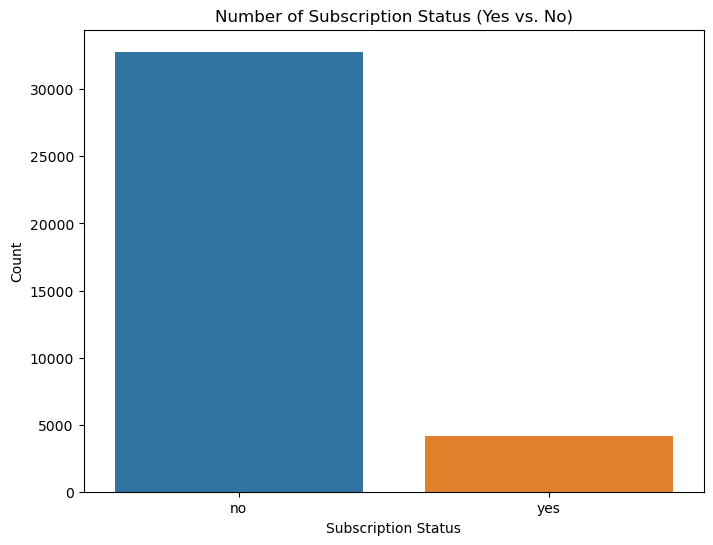

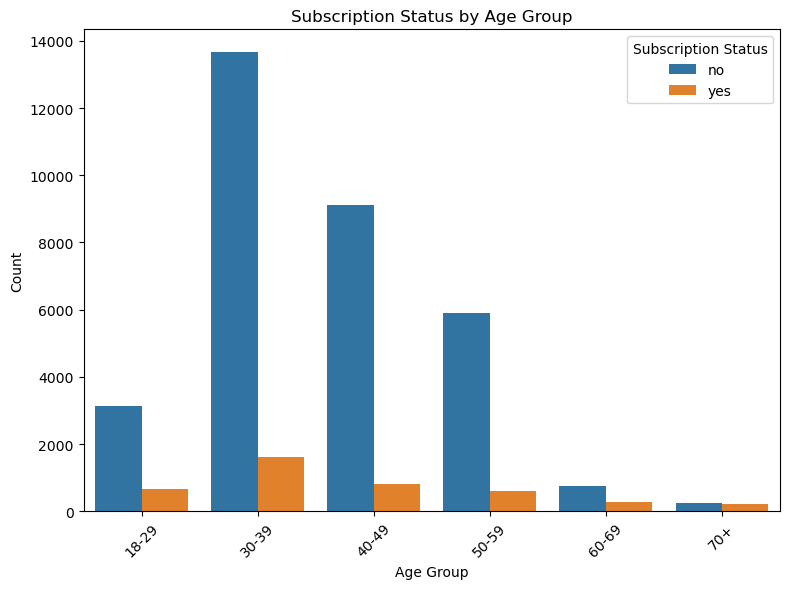

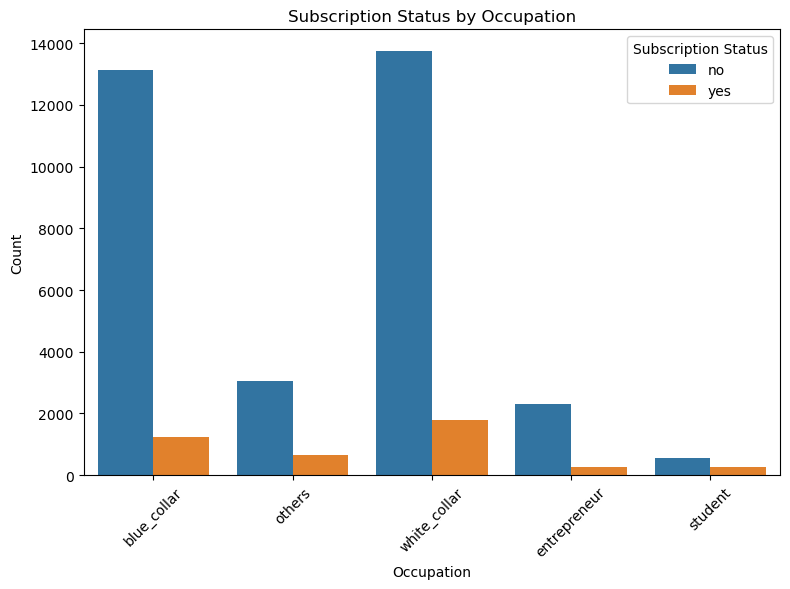

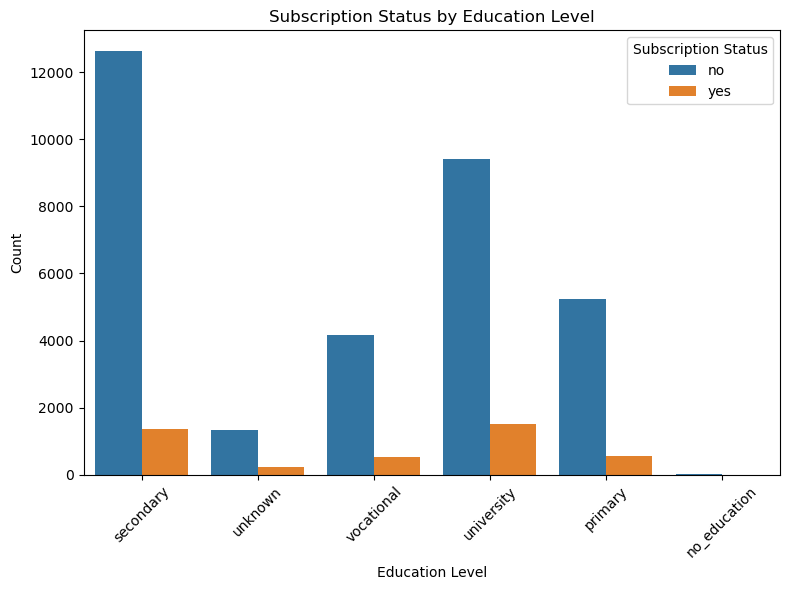

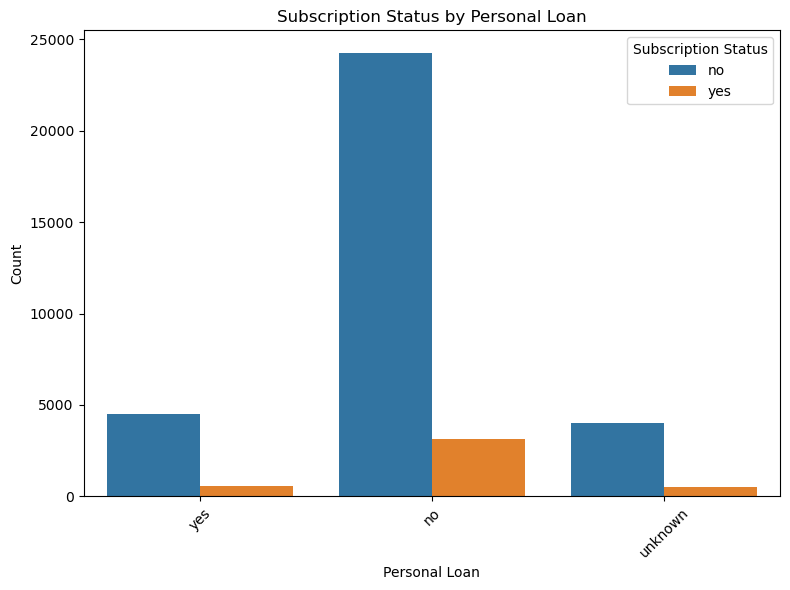

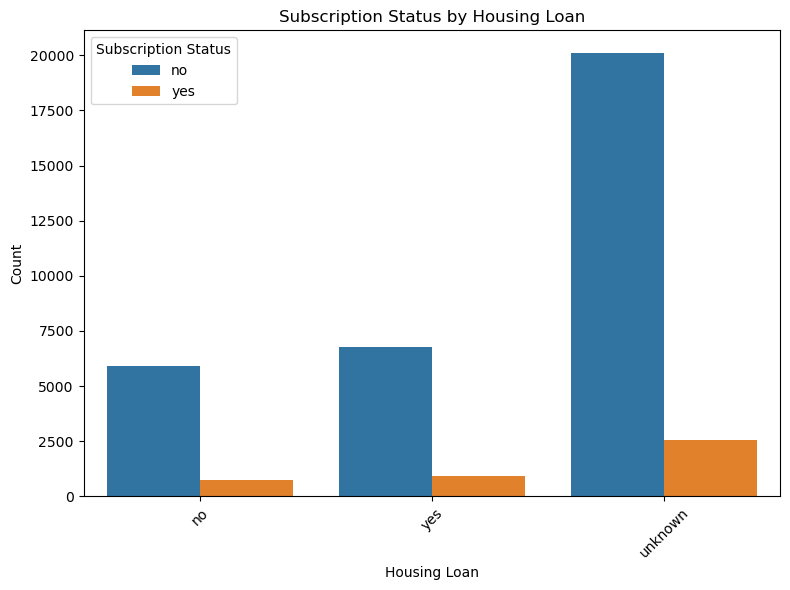

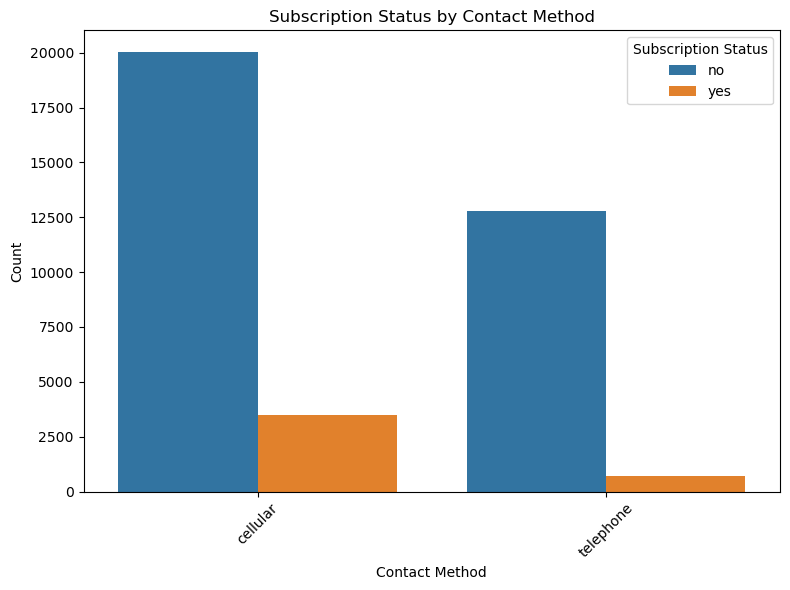

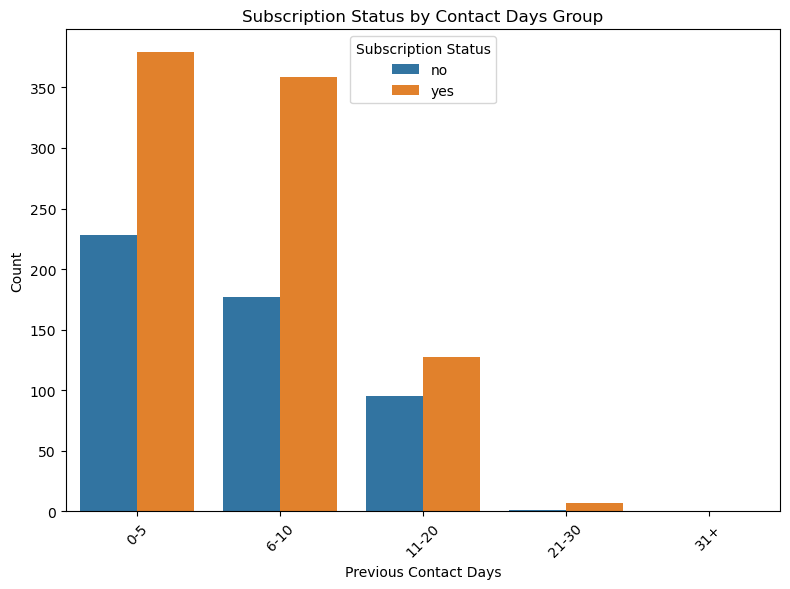

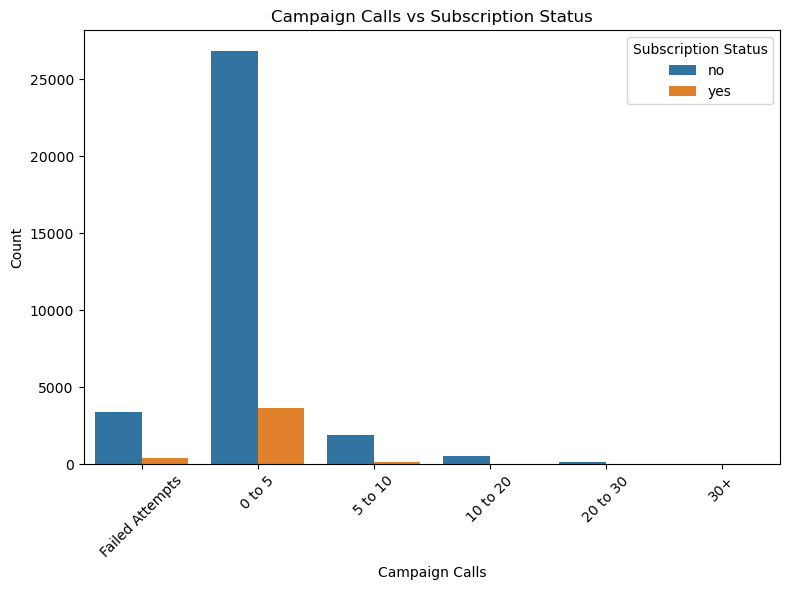

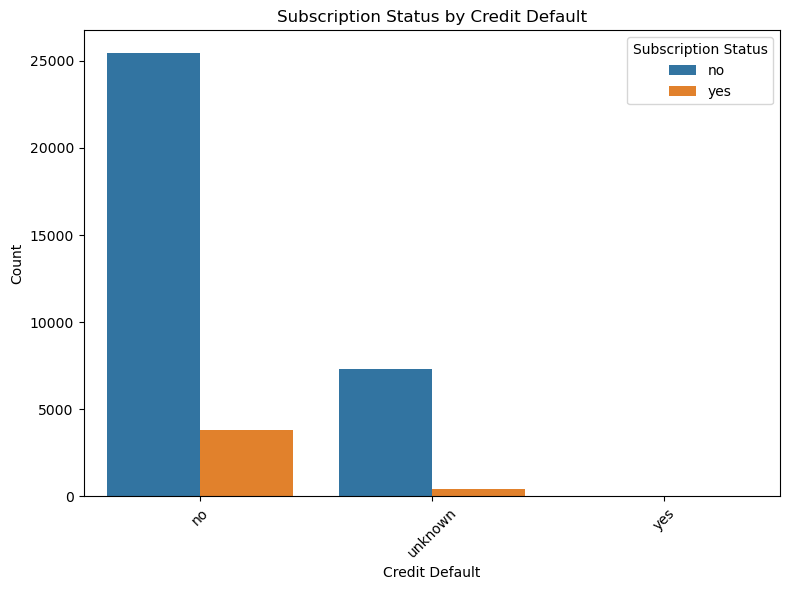

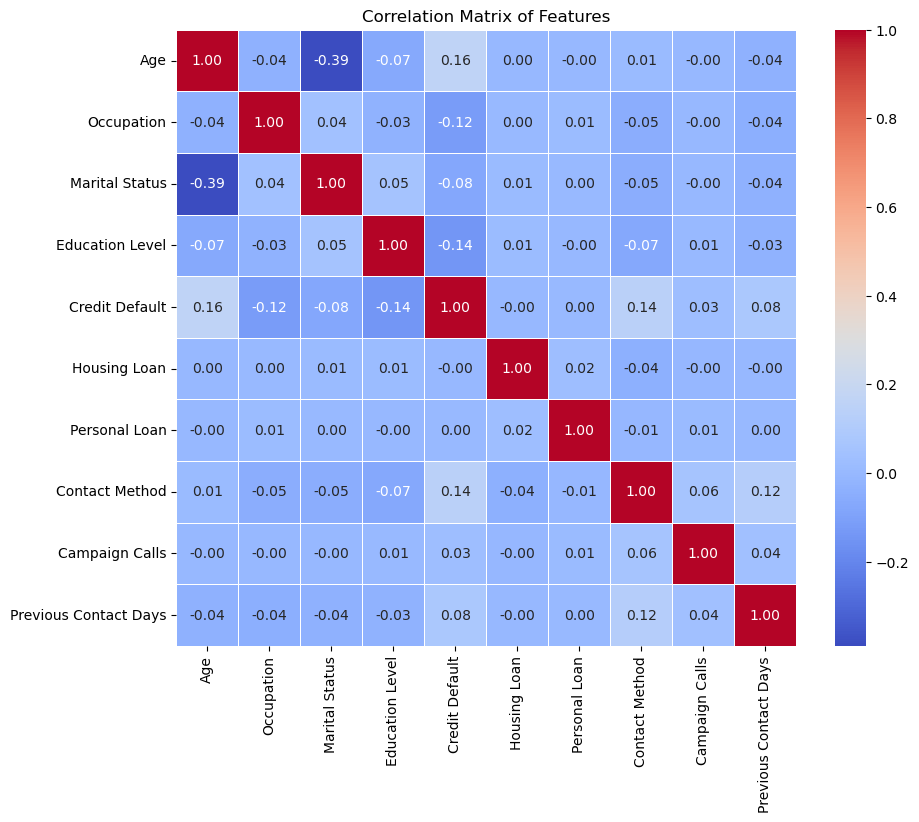

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# create Age Bands
age_bins = [18, 29, 39, 49, 59, 69, 100]
age_labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# create bands for 'Previous Contact Days'
contact_days_bins = [-1, 5, 10, 20, 30, 60]
contact_days_labels = ['0-5', '6-10', '11-20', '21-30', '31+']
df['Contact Days Group'] = pd.cut(df['Previous Contact Days'], bins=contact_days_bins, labels=contact_days_labels, right=False)

# create bands for 'Campaign Calls' (assuming negative numbers for failed attempts)
bins = [-float('inf'), 0, 5, 10, 20, 30, float('inf')]
labels = ['Failed Attempts', '0 to 5', '5 to 10', '10 to 20', '20 to 30', '30+'] 
df['Campaign Calls Binned'] = pd.cut(df['Campaign Calls'], bins=bins, labels=labels)

# count the occurrences of each subscription status
subscription_counts = df['Subscription Status'].value_counts()

# plotting the subscription status counts
plt.figure(figsize=(8, 6))
sns.barplot(x=subscription_counts.index, y=subscription_counts.values)
plt.xlabel('Subscription Status')
plt.ylabel('Count')
plt.title('Number of Subscription Status (Yes vs. No)')
plt.show()

# plot 'Age' group vs 'Subscription Status'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Age Group', hue='Subscription Status')
plt.title('Subscription Status by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot 'Occupation' vs 'Subscription Status'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Occupation', hue='Subscription Status')
plt.title('Subscription Status by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot 'Education Level' vs 'Subscription Status'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Education Level', hue='Subscription Status')
plt.title('Subscription Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot 'Personal Loan' vs 'Subscription Status'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Personal Loan', hue='Subscription Status')
plt.title('Subscription Status by Personal Loan')
plt.xlabel('Personal Loan')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot 'Housing Loan' vs 'Subscription Status'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Housing Loan', hue='Subscription Status')
plt.title('Subscription Status by Housing Loan')
plt.xlabel('Housing Loan')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot 'Contact Method' vs 'Subscription Status'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Contact Method', hue='Subscription Status')
plt.title('Subscription Status by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot 'Previous Contact Days' group vs 'Subscription Status'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Contact Days Group', hue='Subscription Status')
plt.title('Subscription Status by Contact Days Group')
plt.xlabel('Previous Contact Days')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot 'Campaign Calls' group vs 'Subscription Status'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Campaign Calls Binned', hue='Subscription Status',)
plt.title('Campaign Calls vs Subscription Status')
plt.xlabel('Campaign Calls')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot 'Credit Default' vs 'Subscription Status'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Credit Default', hue='Subscription Status')
plt.title('Subscription Status by Credit Default')
plt.xlabel('Credit Default')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# drop binned columns
df = df.drop(columns=[col for col in ['Age Group', 'Contact Days Group', 'Campaign Calls Binned'] if col in df.columns])

# create a label encoder
encoder = LabelEncoder()

# list of categorical columns to encode
categorical_cols = ['Occupation', 'Marital Status', 'Education Level', 'Credit Default', 
                    'Housing Loan', 'Personal Loan', 'Contact Method']

# apply label encoding to categorical columns
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

# define 'X' as the features (all columns except 'Subscription Status')
X = df.drop(['Subscription Status'], axis=1)

# compute the correlation matrix of the features (X)
correlation_matrix = X.corr()

# plot the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.show()

## For Classification Task

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc, roc_auc_score

# initialize the label encoder
encoder = LabelEncoder()

# columns to encode
categorical_cols = ['Occupation', 'Marital Status', 'Education Level', 'Credit Default', 
                    'Housing Loan', 'Personal Loan', 'Contact Method', 'Subscription Status']

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

# split data into features and target
X = df.drop('Subscription Status', axis=1)  # features (excluding target column)
y = df['Subscription Status']  # target variable

# stratified sampling to ensure similar distribution of the target in train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### We use stratified sampling here because it is an imbalanced data.

### Logistic Regression

Accuracy of Logistic Regression: 0.8955264224895256
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      6561
           1       0.62      0.20      0.31       838

    accuracy                           0.90      7399
   macro avg       0.76      0.59      0.62      7399
weighted avg       0.87      0.90      0.87      7399



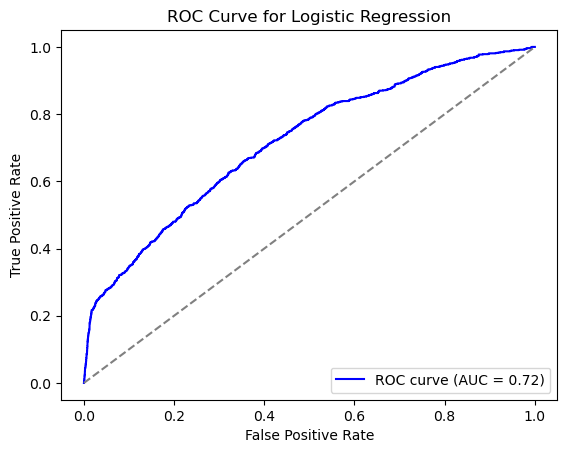

In [9]:
# train the logistic regression model
logreg_model = LogisticRegression(solver='liblinear', random_state=42)
logreg_model.fit(X_train, y_train)

# evaluate model
logreg_accuracy = accuracy_score(y_test, logreg_model.predict(X_test))
print(f"Accuracy of Logistic Regression: {logreg_accuracy}")
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, logreg_model.predict(X_test)))

# calculate ROC curve and AUC in one line
fpr, tpr, _ = roc_curve(y_test, logreg_model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

# plot ROC curve
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line (no-discrimination line)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.show()

### Decision Tree Classifier

Accuracy of Decision Tree: 0.8445735910258143
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      6561
           1       0.29      0.25      0.26       838

    accuracy                           0.84      7399
   macro avg       0.60      0.58      0.59      7399
weighted avg       0.84      0.84      0.84      7399



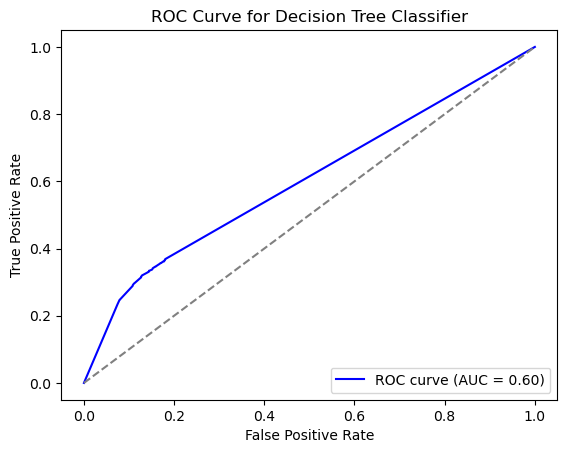

In [10]:
# train the decision tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# evaluate model
dt_accuracy = accuracy_score(y_test, dt_model.predict(X_test))
print(f"Accuracy of Decision Tree: {dt_accuracy}")
print("Classification Report for Decision Tree:")
print(classification_report(y_test, dt_model.predict(X_test)))

# calculate ROC curve and AUC in one line
fpr, tpr, _ = roc_curve(y_test, dt_model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

# plot ROC curve
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line (no-discrimination line)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Decision Tree Classifier')
plt.legend(loc='lower right')
plt.show()

### Random Forest Classifier

Accuracy of Random Forest: 0.8739018786322476
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      6561
           1       0.40      0.24      0.30       838

    accuracy                           0.87      7399
   macro avg       0.66      0.60      0.62      7399
weighted avg       0.85      0.87      0.86      7399



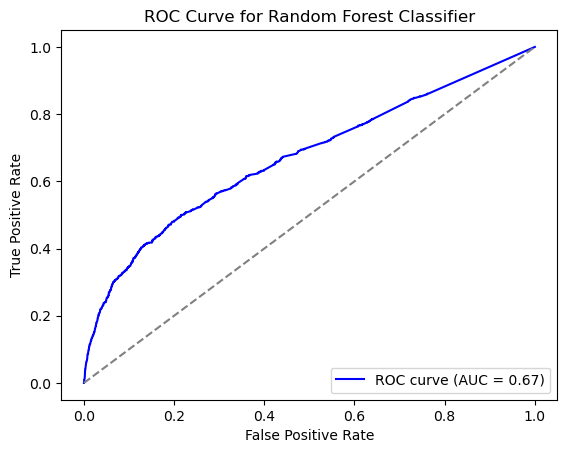

In [11]:
# train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# evaluate model
rf_accuracy = accuracy_score(y_test, rf_model.predict(X_test))
print(f"Accuracy of Random Forest: {rf_accuracy}")
print("Classification Report for Random Forest:")
print(classification_report(y_test, rf_model.predict(X_test)))

# calculate ROC curve and AUC in one line
fpr, tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

# plot ROC curve
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line (no-discrimination line)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest Classifier')
plt.legend(loc='lower right')
plt.show()

### Naive Bayes

Accuracy of Naive Bayes: 0.8943
Classification Report for Naive Bayes:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      6561
           1       0.58      0.24      0.34       838

    accuracy                           0.89      7399
   macro avg       0.75      0.61      0.64      7399
weighted avg       0.87      0.89      0.87      7399



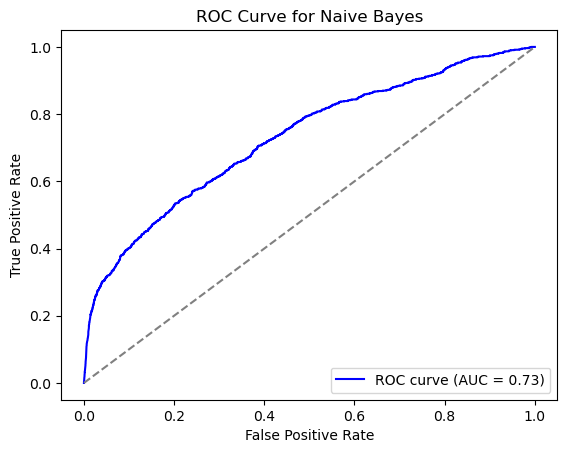

In [12]:
# initialize and train the Naive Bayes model
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train, y_train)

# make predictions
y_pred = naive_bayes_model.predict(X_test)

# evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Naive Bayes: {accuracy:.4f}")
print("Classification Report for Naive Bayes:")
print(classification_report(y_test, y_pred))

# calculate ROC curve and AUC in one line
fpr, tpr, _ = roc_curve(y_test, naive_bayes_model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

# plot ROC curve
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line (no-discrimination line)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Naive Bayes')
plt.legend(loc='lower right')
plt.show()

The results indicate that **Logistic Regression** shows the best performance with an accuracy of 89.55% and an ROC AUC of 0.72, though it struggles with identifying Yes subscribers. 

**Random Forest** performs slightly better than **Decision Tree** on the imbalanced dataset, with an accuracy of 87.39% and an ROC AUC of 0.67. Both models have difficulty with the minority Yes class subscribers. 

**Naive Bayes** delivers comparable performance with an accuracy of 89.43% and an ROC AUC of 0.73, but still struggles with recall for the Yes class. 

To improve results, we will try **XGBoost**.

### XGBoost

Accuracy of XGBoost: 0.8930936613055819
Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      6561
           1       0.57      0.24      0.33       838

    accuracy                           0.89      7399
   macro avg       0.74      0.61      0.64      7399
weighted avg       0.87      0.89      0.87      7399

ROC-AUC Score: 0.73


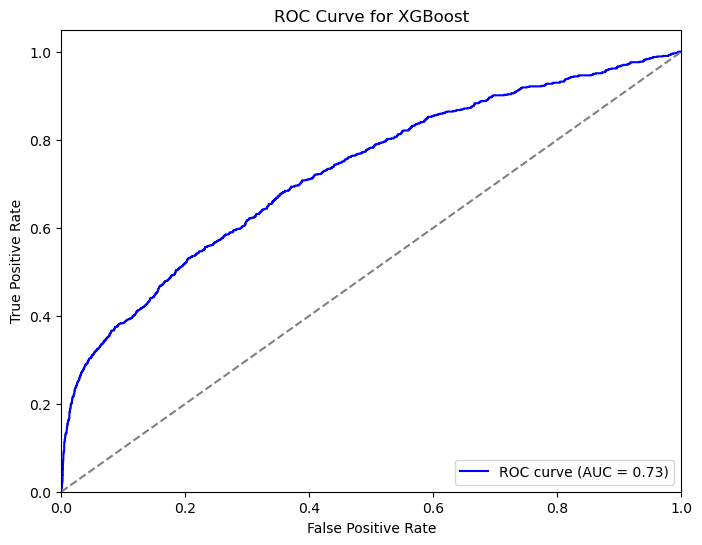

In [13]:
import xgboost as xgb

# convert the data into DMatrix format for XGBoost (optional but efficient for large datasets)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# define the model parameters for XGBoost
params = {
    'objective': 'binary:logistic',  # binary classification
    'eval_metric': 'logloss',        # evaluation metric (log loss)
    'max_depth': 6,                  # max depth of the tree
    'eta': 0.1,                      # learning rate
    'subsample': 0.8,                # fraction of data used for each tree
    'colsample_bytree': 0.8,         # fraction of features used for each tree
    'scale_pos_weight': 1.5,         # balancing the class weights (important for imbalanced data)
}

# train the XGBoost model
model = xgb.train(params, dtrain, num_boost_round=100)

# make predictions
y_pred = model.predict(dtest)

# convert probabilities to binary outcomes (0 or 1)
y_pred_binary = [1 if i > 0.5 else 0 for i in y_pred]

# evaluate the model
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Accuracy of XGBoost: {accuracy}")
print("Classification Report for XGBoost:")
print(classification_report(y_test, y_pred_binary))

# calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred)
print(f"ROC-AUC Score: {roc_auc:.2f}")

# plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line (no-discrimination line)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc='lower right')
plt.show()

**Logistic Regression** is the best model with the highest accuracy (89.55%) and a ROC AUC of 0.72, but has low recall for the Yes class. 

**XGBoost** (accuracy: 89.31%, ROC AUC: 0.73) offers a slight improvement in AUC but still struggles with Yes class recall. 

**Random Forest** and **Decision Tree** perform worse, with ROC AUC scores of 0.67 and 0.60, respectively, and also show bias toward the majority class. 

**Naive Bayes** (accuracy: 89.43%, ROC AUC: 0.73) shows similar performance to **XGBoost**, with a slightly better accuracy and a comparable ROC AUC, but still faces challenges with the minority class recall. 

While **XGBoost** and **Naive Bayes** offer good performance, class balancing and data augmentation are crucial for improving recall for the Yes class.